# 马科维兹投资组合理论 — 学习笔记

本 notebook 用 **4 个资产**的数值例子，把马科维兹理论跑通一遍：先定义输入 → 算协方差 → 蒙特卡洛随机权重 → 画可行集 → 找关键组合。

下方 **Cell 1** 是向量化写法（推荐）；**Cell 2** 是循环写法，公式相同，便于对照理解。

---

## 一、本例用的 4 个资产（对应代码 `mus` / `sigmas`）

| 资产 | 代码变量 | 预期收益率 $\mu_i$ | 标准差 $\sigma_i$ |
|------|----------|-------------------|-------------------|
| 股票A | `mus[0]`, `sigmas[0]` | 12% | 25% |
| 股票B | `mus[1]`, `sigmas[1]` | 9% | 18% |
| 债券 | `mus[2]`, `sigmas[2]` | 4% | 6% |
| 黄金/商品 | `mus[3]`, `sigmas[3]` | 7% | 15% |

相关系数存在 `rho_matrix`（4×4 对称矩阵，对角线为 1）。例如股票 A、B 相关系数 0.70（同涨同跌），债券与其他资产相关性较低（分散化效果好）。

---

## 二、理论公式 ↔ 代码变量（逐步对应）

### 步骤 1：定义输入 → `mus`, `sigmas`, `rho_matrix`

### 步骤 2：算协方差矩阵 → `cov_matrix`

理论：$\text{cov}_{ij} = \rho_{ij} \cdot \sigma_i \cdot \sigma_j$

- **Cell 1**：`cov_matrix = np.outer(sigmas, sigmas) * rho_matrix`（一行向量化）
- **Cell 2**：双重 `for` 循环逐元素赋值（逻辑相同）

### 步骤 3：随机生成权重 → `weights`

理论约束：$w_i \geq 0$，且 $\sum_i w_i = 1$（全额投资、不做空）

代码做法：先生成 `[0,1)` 随机数，再 **归一化** `weights / weights.sum(...)`，保证每行权重和为 1。

### 步骤 4：算组合收益与风险

| 理论 | 代码（Cell 1 向量化） | 代码（Cell 2 循环） |
|------|----------------------|---------------------|
| $E[r_p] = \sum w_i \mu_i$ | `port_returns = weights @ mus` | `np.dot(weights, mus)` |
| $\sigma_p^2 = \mathbf{w}^T \mathbf{\Sigma} \mathbf{w}$ | `np.einsum('ij,jk,ik->i', weights, cov_matrix, weights)` | `np.dot(weights.T, np.dot(cov_matrix, weights))` |
| $\sigma_p = \sqrt{\sigma_p^2}$ | `port_vols = np.sqrt(port_vars)` | `port_vol = np.sqrt(port_var)` |

### 步骤 5：夏普比率 → `sharpe_ratios`

本笔记设无风险利率 $r_f = 0$，所以：

$$SR = \frac{E[r_p]}{\sigma_p}$$

对应代码：`sharpe_ratios = port_returns / port_vols`（Cell 2 在画图时用 `port_returns/port_vols` 上色，含义相同）

### 步骤 6：找关键组合

| 目标 | 理论含义 | 代码 |
|------|----------|------|
| 最小方差组合 | 可行集里风险最低的点 | `min_vol_idx = np.argmin(port_vols)` |
| 最高夏普比率组合 | 收益/风险比最大（散点图颜色最亮处） | `max_sharpe_idx = np.argmax(sharpe_ratios)` |

---

## 三、图里画了什么（对应可视化代码）

横轴 `port_vols` = 组合标准差（风险），纵轴 `port_returns` = 组合预期收益：

1. **彩色散点云**：10 万 / 200 万组随机权重对应的全部组合（即**可行集**的蒙特卡洛近似）
2. **红/绿/蓝/紫大点**：4 个单一资产，坐标为 `(sigmas[i], mus[i])` — 相当于 100% 持有某一资产
3. **橙色 ★**：`min_vol_idx` 标注的最小方差组合
4. **金色 P**：`max_sharpe_idx` 标注的最高夏普比率组合
5. **颜色条**：夏普比率高低（`viridis` 配色）

运行后 `print` 会输出两类组合的风险、收益，以及各自权重分配。

---

## 四、两个 Cell 的区别（其余逻辑一致）

| | Cell 1（向量化） | Cell 2（循环） |
|--|-----------------|----------------|
| 模拟次数 | `n_simulations = 100_000` | `n_simulations = 2_000_000` |
| 权重生成 | 一次生成 `(n_sim, 4)` 矩阵 | `for` 循环逐组生成 |
| 协方差计算 | `np.outer` 一行搞定 | 双重循环 |
| 第 4 资产标签 | `'黄金'` | `'商品'` |
| 权重输出 | MVP + 最高夏普 都打印 | 只打印最高夏普权重 |

> **读图要点**：散点云左边界附近是有效前沿的近似；组合点落在单资产点**左下方或内侧**，说明分散化降低了风险（因为 $\rho_{ij} < 1$）。

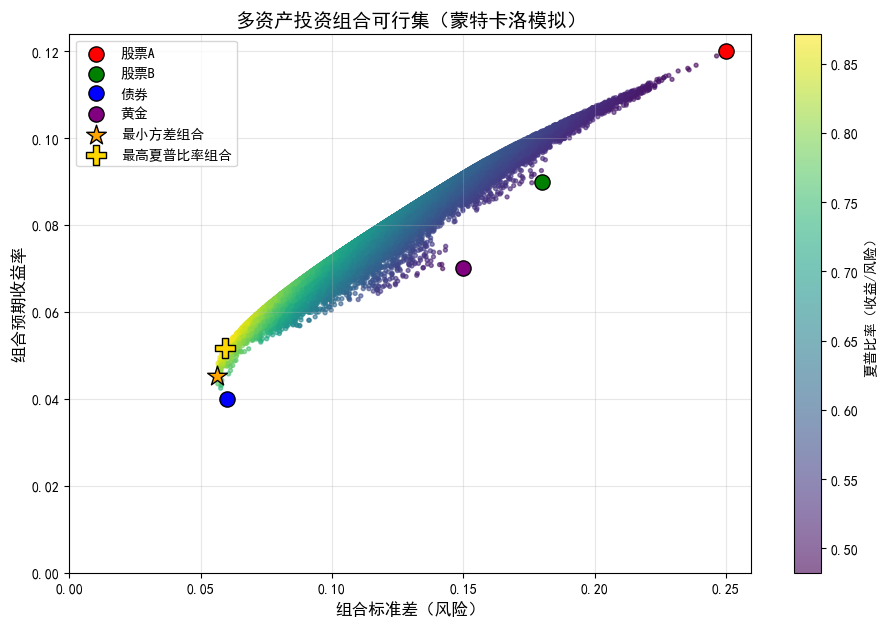

=== 关键组合信息 ===
最小方差组合 - 风险: 0.0563, 收益: 0.0453
最高夏普比率组合 - 风险: 0.0592, 收益: 0.0516

最小方差组合权重：
  股票A: 0.0054
  股票B: 0.0506
  债券: 0.8649
  黄金: 0.0791

最高夏普比率组合权重：
  股票A: 0.0021
  股票B: 0.1347
  债券: 0.7067
  黄金: 0.1565


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # 忽略无关警告

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签（黑体）
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号（避免中文显示时负号变成方块）

# ===================== 1. 定义多资产基础参数 =====================
# 资产：股票A、股票B、债券、黄金
asset_labels = ['股票A', '股票B', '债券', '黄金']
mus = np.array([0.12, 0.09, 0.04, 0.07])    # 预期收益率
sigmas = np.array([0.25, 0.18, 0.06, 0.15]) # 标准差（风险）

# 相关系数矩阵（对称矩阵，对角线为1）
rho_matrix = np.array([
    [1.00, 0.70, 0.20, 0.30],
    [0.70, 1.00, 0.10, 0.20],
    [0.20, 0.10, 1.00, 0.05],
    [0.30, 0.20, 0.05, 1.00],
])

# 协方差矩阵：cov_ij = rho_ij * sigma_i * sigma_j
cov_matrix = np.outer(sigmas, sigmas) * rho_matrix

# ===================== 2. 蒙特卡洛模拟 =====================
np.random.seed(42)  # 固定随机种子，结果可复现
n_simulations = 100000  # 模拟组合数量
n_assets = len(mus)

# 随机权重并归一化（每行一组权重，且和为1）
weights = np.random.random((n_simulations, n_assets))
weights = weights / weights.sum(axis=1, keepdims=True)

# 组合收益与风险（向量化计算）
port_returns = weights @ mus
port_vars = np.einsum('ij,jk,ik->i', weights, cov_matrix, weights)
port_vols = np.sqrt(port_vars)
sharpe_ratios = port_returns / port_vols

# 找到关键组合
min_vol_idx = np.argmin(port_vols)
max_sharpe_idx = np.argmax(sharpe_ratios)

# ===================== 3. 可视化可行集 =====================
plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    port_vols, port_returns,
    c=sharpe_ratios,
    cmap='viridis',
    alpha=0.6,
    s=8
)

# 标注单个资产
asset_colors = ['red', 'green', 'blue', 'purple']
for i in range(n_assets):
    plt.scatter(
        sigmas[i], mus[i],
        color=asset_colors[i], s=120, label=asset_labels[i],
        edgecolors='black', zorder=5
    )

# 标注最小方差组合
plt.scatter(
    port_vols[min_vol_idx], port_returns[min_vol_idx],
    color='orange', s=220, marker='*',
    label='最小方差组合', edgecolors='black', zorder=10
)

# 标注最高夏普比率组合
plt.scatter(
    port_vols[max_sharpe_idx], port_returns[max_sharpe_idx],
    color='gold', s=220, marker='P',
    label='最高夏普比率组合', edgecolors='black', zorder=10
)

plt.colorbar(scatter, label='夏普比率（收益/风险）')
plt.xlabel('组合标准差（风险）', fontsize=12)
plt.ylabel('组合预期收益率', fontsize=12)
plt.title('多资产投资组合可行集（蒙特卡洛模拟）', fontsize=14)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()

# ===================== 4. 输出关键信息 =====================
print('=== 关键组合信息 ===')
print(f'最小方差组合 - 风险: {port_vols[min_vol_idx]:.4f}, 收益: {port_returns[min_vol_idx]:.4f}')
print(f'最高夏普比率组合 - 风险: {port_vols[max_sharpe_idx]:.4f}, 收益: {port_returns[max_sharpe_idx]:.4f}')

print('\n最小方差组合权重：')
for i, name in enumerate(asset_labels):
    print(f'  {name}: {weights[min_vol_idx][i]:.4f}')

print('\n最高夏普比率组合权重：')
for i, name in enumerate(asset_labels):
    print(f'  {name}: {weights[max_sharpe_idx][i]:.4f}')

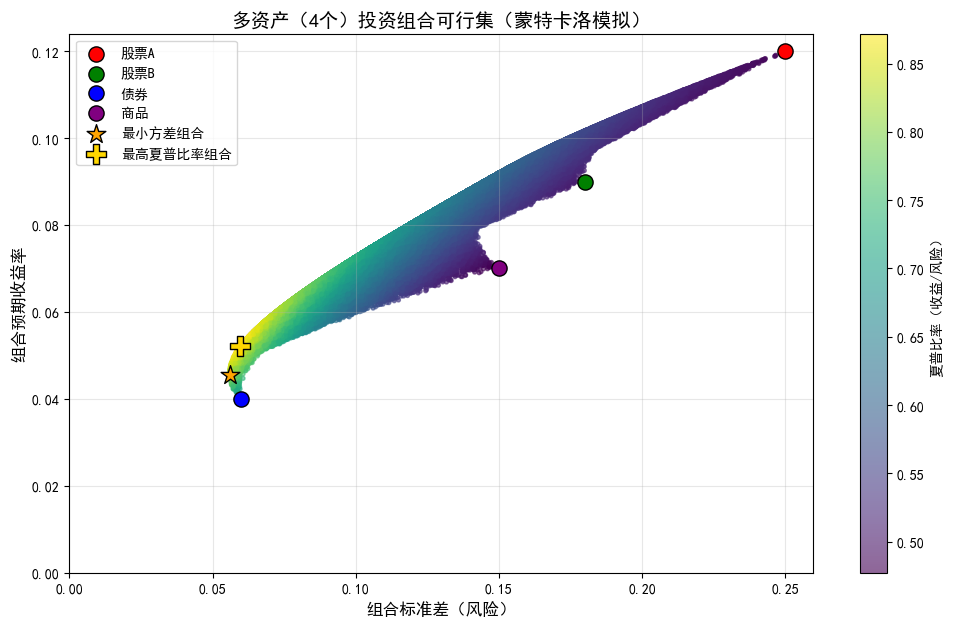

=== 关键组合信息 ===
最小方差组合 - 风险: 0.0559, 收益: 0.0454
最高夏普比率组合 - 风险: 0.0598, 收益: 0.0521

最高夏普比率组合的权重分配：
  股票A: 0.0026
  股票B: 0.1362
  债券: 0.6916
  商品: 0.1697


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # 忽略无关警告

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签（黑体）
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号（避免中文显示时负号变成方块）
# ===================== 1. 定义多资产基础参数 =====================
# 定义4个资产的预期收益、标准差（可根据需要增减资产）
# 资产1：股票A | 资产2：股票B | 资产3：债券 | 资产4：商品
mus = np.array([0.12, 0.09, 0.04, 0.07])    # 4个资产的预期收益率
sigmas = np.array([0.25, 0.18, 0.06, 0.15]) # 4个资产的标准差

# 定义4×4的相关系数矩阵（必须是对称矩阵，对角线为1）
# 行/列对应：资产1、资产2、资产3、资产4
rho_matrix = np.array([
    [1.0, 0.7, 0.2, 0.3],  # 资产1与各资产的相关系数
    [0.7, 1.0, 0.1, 0.2],  # 资产2与各资产的相关系数
    [0.2, 0.1, 1.0, 0.05], # 资产3与各资产的相关系数
    [0.3, 0.2, 0.05, 1.0]  # 资产4与各资产的相关系数
])

# 计算协方差矩阵（核心：cov = ρ * σ_i * σ_j）
cov_matrix = np.zeros_like(rho_matrix)
for i in range(len(rho_matrix)):
    for j in range(len(rho_matrix)):
        cov_matrix[i, j] = rho_matrix[i, j] * sigmas[i] * sigmas[j]

# ===================== 2. 蒙特卡洛模拟（多资产权重） =====================
np.random.seed(42)  # 固定随机种子，结果可复现
n_simulations = 2000000  # 模拟20000组权重（多资产需更多模拟点）
n_assets = len(mus)    # 资产数量

# 存储结果的数组
port_returns = []  # 组合预期收益
port_vols = []     # 组合标准差（风险）
weights_list = []  # 权重组合

for _ in range(n_simulations):
    # 随机生成权重（0~1之间），然后归一化（保证权重和为1）
    weights = np.random.random(n_assets)  
    weights = weights / np.sum(weights)  # 归一化，核心操作！
    
    # 计算组合预期收益：E[r_p] = Σ(w_i * μ_i)
    port_return = np.dot(weights, mus)
    
    # 计算组合方差：σ_p² = ΣΣ(w_i * w_j * cov_ij)
    port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    port_vol = np.sqrt(port_var)  # 标准差（风险）
    
    # 存储结果
    port_returns.append(port_return)
    port_vols.append(port_vol)
    weights_list.append(weights)

# 转换为numpy数组（方便后续处理）
port_returns = np.array(port_returns)
port_vols = np.array(port_vols)
weights_list = np.array(weights_list)

# ===================== 3. 可视化多资产可行集 =====================
plt.figure(figsize=(12, 7))

# 绘制蒙特卡洛模拟的所有组合点
scatter = plt.scatter(port_vols, port_returns, 
                     c=port_returns/port_vols,  # 颜色映射：夏普比率（收益/风险）
                     cmap='viridis',            # 配色方案
                     alpha=0.6,                 # 透明度
                     s=8)                       # 点大小

# 标注单个资产的位置
asset_colors = ['red', 'green', 'blue', 'purple']  # 每个资产对应一种颜色
asset_labels = ['股票A', '股票B', '债券', '商品']   # 资产标签
for i in range(n_assets):
    plt.scatter(sigmas[i], mus[i], 
               color=asset_colors[i], s=120, label=asset_labels[i], 
               edgecolors='black', zorder=5)  # zorder让资产点在最上层

# 找到最小方差组合（风险最低的点）
min_vol_idx = np.argmin(port_vols)
plt.scatter(port_vols[min_vol_idx], port_returns[min_vol_idx], 
           color='orange', s=200, label='最小方差组合', 
           edgecolors='black', marker='*', zorder=10)

# 找到最高夏普比率组合（收益/风险比最高）
sharpe_ratios = port_returns / port_vols
max_sharpe_idx = np.argmax(sharpe_ratios)
plt.scatter(port_vols[max_sharpe_idx], port_returns[max_sharpe_idx], 
           color='gold', s=200, label='最高夏普比率组合', 
           edgecolors='black', marker='P', zorder=10)  # P形标记

# 图表美化
plt.colorbar(scatter, label='夏普比率（收益/风险）')
plt.xlabel('组合标准差（风险）', fontsize=12)
plt.ylabel('组合预期收益率', fontsize=12)
plt.title('多资产（4个）投资组合可行集（蒙特卡洛模拟）', fontsize=14)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(left=0)  # 风险轴从0开始，更直观
plt.ylim(bottom=0) # 收益轴从0开始
plt.show()

# ===================== 4. 输出关键信息 =====================
print("=== 关键组合信息 ===")
print(f"最小方差组合 - 风险: {port_vols[min_vol_idx]:.4f}, 收益: {port_returns[min_vol_idx]:.4f}")
print(f"最高夏普比率组合 - 风险: {port_vols[max_sharpe_idx]:.4f}, 收益: {port_returns[max_sharpe_idx]:.4f}")
print("\n最高夏普比率组合的权重分配：")
for i in range(n_assets):
    print(f"  {asset_labels[i]}: {weights_list[max_sharpe_idx][i]:.4f}")